# B6 Transmission Headroom & Scottish Wind Balancing

## A day-ahead predictive analysis of the GB electricity system

This notebook asks whether information published a day ahead about the B6 transmission boundary helps predict later downward Balancing Mechanism activity on Scottish wind units.

I use a broader B6 and balancing sample for descriptive analysis, then a smaller verified-wind sample for modelling. The modelling sample only keeps dates where the historic wind forecast can be shown to have been available before delivery.

Wind matters because the same high-wind conditions that tighten north-to-south transfers can also increase the amount of Scottish wind exposed to downward balancing. The model comparison therefore asks a narrower question: does B6 headroom still add useful information after forecast wind, forecast demand and calendar effects are already included?

The results are predictive, not causal. B6 is one part of a wider transmission system, and the BOA data do not identify which network boundary caused each individual action.


## 1. Setup

In [691]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sqlalchemy import create_engine

In [692]:
engine = create_engine(
    "postgresql+psycopg2://oconnor@localhost/gb_power_b6"
)

In [693]:
full = pd.read_sql(
    "SELECT * FROM mart.model_full;",
    engine
)

wind = pd.read_sql(
    "SELECT * FROM mart.model_verified_wind;",
    engine
)

for df in [full, wind]:
    df["settlement_date"] = pd.to_datetime(
        df["settlement_date"]
    )

In [694]:
print(full.shape)
print(wind.shape)

(42332, 16)
(31532, 20)


## 2. Modelling datasets

The modelling tables were built and checked in PostgreSQL before being loaded into Python.

The **full sample** contains the day-ahead B6 variables, demand forecast, Scottish wind BOA outcome and calendar variables.

The **verified-wind sample** also includes the historic day-ahead wind forecast. I only keep dates where the timing of that forecast can be verified as being available before delivery.

This smaller sample is used for the main predictive models because forecast wind is an important factor in both transmission conditions and Scottish wind balancing activity.

In [695]:
sample_overview = pd.DataFrame({
    "sample": ["full", "verified_wind"],
    "rows": [len(full), len(wind)],
    "days": [
        full["settlement_date"].nunique(),
        wind["settlement_date"].nunique()
    ],
    "first_date": [
        full["settlement_date"].min(),
        wind["settlement_date"].min()
    ],
    "last_date": [
        full["settlement_date"].max(),
        wind["settlement_date"].max()
    ]
})

sample_overview

,sample,rows,days,first_date,last_date
0,full,42332,882,2024-04-22,2026-09-30
1,verified_wind,31532,657,2024-04-22,2026-04-23


## 3. Initial data validation

Before looking at the relationship between B6 conditions and Scottish wind balancing activity, I check that each sample has one row per settlement period, identify any missing values and flag unusual B6 observations that may need separate treatment later.

In [696]:
validation = pd.DataFrame({
    "sample": ["full", "verified_wind"],
    "rows": [len(full), len(wind)],
    "days": [
        full["settlement_date"].nunique(),
        wind["settlement_date"].nunique()
    ],
    "duplicate_keys": [
        full.duplicated(
            ["settlement_date", "settlement_period"]
        ).sum(),
        wind.duplicated(
            ["settlement_date", "settlement_period"]
        ).sum()
    ],
    "missing_values": [
        full.isna().sum().sum(),
        wind.isna().sum().sum()
    ]
})

validation

,sample,rows,days,duplicate_keys,missing_values
0,full,42332,882,0,11
1,verified_wind,31532,657,0,11


In [697]:
pd.DataFrame({
    "full_missing": full.isna().sum(),
    "verified_wind_missing": wind.isna().sum()
}).query(
    "full_missing > 0 or verified_wind_missing > 0"
)

,full_missing,verified_wind_missing
b6_utilisation,11.0,11


In [698]:
for df in [full, wind]:
    df["b6_zero_limit_flag"] = (
        df["b6_limit_mw"] == 0
    ).astype(int)

print(
    "Full sample zero-limit periods:",
    full["b6_zero_limit_flag"].sum()
)

print(
    "Verified-wind zero-limit periods:",
    wind["b6_zero_limit_flag"].sum()
)

Full sample zero-limit periods: 11
Verified-wind zero-limit periods: 11


In [701]:
full = pd.read_sql("SELECT * FROM mart.model_full;", engine)
wind = pd.read_sql("SELECT * FROM mart.model_verified_wind;", engine)

#### B6 utilisation undefined when the published limit is zero

Eleven settlement periods on 17 August 2024 have a published B6 transfer limit of 0 MW. 
The utilisation measure, defined as forecast flow divided by the published limit, is therefore mathematically undefined for these periods.

These observations are retained because the underlying limit, flow and headroom variables remain observed. 
The utilisation values are not imputed. A separate zero-limit indicator is retained so that this unusual operating regime can be identified in later robustness analysis.

In [702]:
print(full.shape)
print(wind.shape)

display(full.head())
display(wind.head())

(42332, 16)
(31532, 20)


,settlement_date,settlement_period,source_clock_ts,b6_limit_mw,b6_forecast_flow_mw,b6_headroom_mw,b6_flow_minus_limit_mw,b6_utilisation,b6_limit_10000_flag,demand_forecast_mw,scottish_downward_boa_mw,scottish_downward_boa_event,curtailed_generators,month,day_of_week,hour_of_day
0,2024-04-30,40,2024-04-30 19:30:00,2800.0,4823.0,-2023.0,2023.0,1.7225,0,31040.0,2239.718,1,17,4,2,19
1,2024-08-11,14,2024-08-11 06:30:00,2500.0,438.0,2062.0,-2062.0,0.1752,0,17455.0,0.000,0,0,8,7,6
2,2025-03-02,45,2025-03-02 22:00:00,5000.0,8463.0,-3463.0,3463.0,1.6926,0,27768.0,3788.152,1,41,3,7,22
3,2025-10-11,24,2025-10-11 11:30:00,4300.0,3870.0,430.0,-430.0,0.9000,0,24696.0,817.600,1,14,10,6,11
4,2024-05-31,27,2024-05-31 13:00:00,2500.0,779.0,1721.0,-1721.0,0.3116,0,23847.0,0.000,0,0,5,5,13


,settlement_date,settlement_period,source_clock_ts,b6_limit_mw,b6_forecast_flow_mw,b6_headroom_mw,b6_flow_minus_limit_mw,b6_utilisation,b6_limit_10000_flag,demand_forecast_mw,scottish_downward_boa_mw,scottish_downward_boa_event,curtailed_generators,month,day_of_week,hour_of_day,wind_forecast_mw,wind_capacity_mw,wind_forecast_capacity_factor,residual_demand_forecast_mw
0,2025-01-14,17,2025-01-14 08:00:00,4800.0,5652.0,-852.0,852.0,1.1775,0,39399.0,1511.336,1,14,1,2,8,12054.0,22052.0,0.546617,27345.0
1,2025-01-30,11,2025-01-30 05:00:00,5500.0,6160.0,-660.0,660.0,1.1200,0,23823.0,451.652,1,8,1,4,5,10757.0,22052.0,0.487802,13066.0
2,2025-02-20,27,2025-02-20 13:00:00,10000.0,9224.0,776.0,-776.0,0.9224,1,31629.0,4062.870,1,43,2,4,13,17852.0,22142.0,0.806251,13777.0
3,2025-05-31,41,2025-05-31 20:00:00,3300.0,4257.0,-957.0,957.0,1.2900,0,23537.0,2336.110,1,47,5,6,20,10568.0,22944.0,0.460600,12969.0
4,2025-08-03,19,2025-08-03 09:00:00,3000.0,3411.0,-411.0,411.0,1.1370,0,20202.0,1383.418,1,35,8,7,9,7897.0,23234.0,0.339890,12305.0


## 4. Exploratory Data Analysis

The exploratory analysis focuses on:

1. the distribution of the Scottish downward BOA outcome;
2. the distribution of B6 headroom;
3. how downward BOA event frequency and volume vary with B6 headroom;
4. relationships with forecast demand and wind;
5. potential non-linearity and unusual B6 operating regimes.

In [703]:
full.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42332 entries, 0 to 42331
Data columns (total 16 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   settlement_date              42332 non-null  object        
 1   settlement_period            42332 non-null  int64         
 2   source_clock_ts              42332 non-null  datetime64[ns]
 3   b6_limit_mw                  42332 non-null  float64       
 4   b6_forecast_flow_mw          42332 non-null  float64       
 5   b6_headroom_mw               42332 non-null  float64       
 6   b6_flow_minus_limit_mw       42332 non-null  float64       
 7   b6_utilisation               42321 non-null  float64       
 8   b6_limit_10000_flag          42332 non-null  int64         
 9   demand_forecast_mw           42332 non-null  float64       
 10  scottish_downward_boa_mw     42332 non-null  float64       
 11  scottish_downward_boa_event  42332 non-nu

In [704]:
wind.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31532 entries, 0 to 31531
Data columns (total 20 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   settlement_date                31532 non-null  object        
 1   settlement_period              31532 non-null  int64         
 2   source_clock_ts                31532 non-null  datetime64[ns]
 3   b6_limit_mw                    31532 non-null  float64       
 4   b6_forecast_flow_mw            31532 non-null  float64       
 5   b6_headroom_mw                 31532 non-null  float64       
 6   b6_flow_minus_limit_mw         31532 non-null  float64       
 7   b6_utilisation                 31521 non-null  float64       
 8   b6_limit_10000_flag            31532 non-null  int64         
 9   demand_forecast_mw             31532 non-null  float64       
 10  scottish_downward_boa_mw       31532 non-null  float64       
 11  scottish_downwa

### 4.1 Scottish downward wind BOA outcome

Before modelling B6 conditions, I first look at how often downward wind BOA activity occurs and how large the observed volume is when it does occur.

In [705]:
positive_boa = full.loc[
    full["scottish_downward_boa_mw"] > 0,
    "scottish_downward_boa_mw"
]

outcome_summary = pd.Series({
    "settlement_periods": len(full),
    "boa_event_periods": int(
        full["scottish_downward_boa_event"].sum()
    ),
    "boa_event_rate_pct": (
        100 * full["scottish_downward_boa_event"].mean()
    ),
    "mean_boa_all_periods_mw": (
        full["scottish_downward_boa_mw"].mean()
    ),
    "median_boa_all_periods_mw": (
        full["scottish_downward_boa_mw"].median()
    ),
    "mean_positive_boa_mw": positive_boa.mean(),
    "median_positive_boa_mw": positive_boa.median(),
    "p90_positive_boa_mw": positive_boa.quantile(0.90),
    "maximum_positive_boa_mw": positive_boa.max(),
    "positive_boa_skewness": positive_boa.skew()
})

outcome_summary.round(2)

settlement_periods           42332.00
boa_event_periods            25836.00
boa_event_rate_pct              61.03
mean_boa_all_periods_mw       1151.13
median_boa_all_periods_mw      321.79
mean_positive_boa_mw          1886.12
median_positive_boa_mw        1556.48
p90_positive_boa_mw           4188.44
maximum_positive_boa_mw       7454.98
positive_boa_skewness            0.79
dtype: float64

Downward wind BOA activity is recorded in 61% of settlement periods, so the outcome contains a sizeable group of zero observations.

When activity is positive, the mean volume is about 1,886 MW and the median is about 1,556 MW. The upper tail is also fairly wide, with the 90th percentile above 4 GW and a maximum of about 7.5 GW.

Because the outcome has both a clear event component and a separate positive-volume distribution, I model these two parts separately later in the notebook.

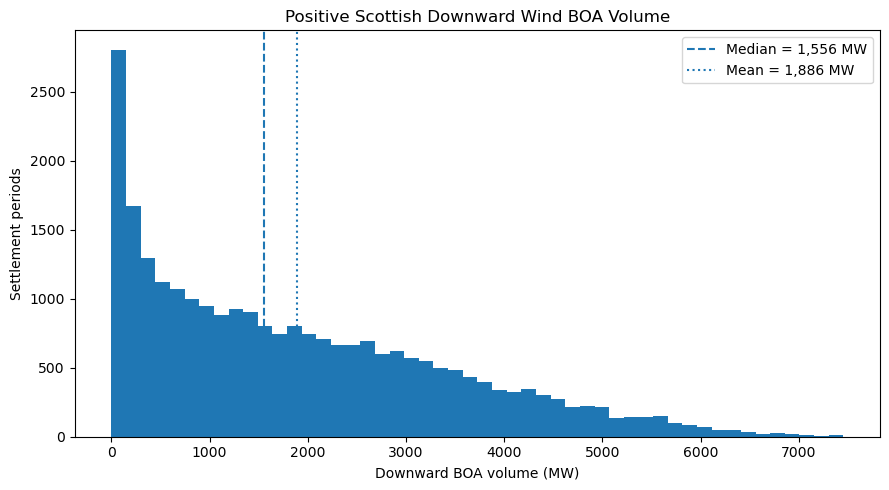

In [706]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(
    positive_boa,
    bins=50
)

ax.axvline(
    positive_boa.median(),
    linestyle="--",
    linewidth=1.5,
    label=f"Median = {positive_boa.median():,.0f} MW"
)

ax.axvline(
    positive_boa.mean(),
    linestyle=":",
    linewidth=1.5,
    label=f"Mean = {positive_boa.mean():,.0f} MW"
)

ax.set_title("Positive Scottish Downward Wind BOA Volume")
ax.set_xlabel("Downward BOA volume (MW)")
ax.set_ylabel("Settlement periods")
ax.legend()

plt.tight_layout()
plt.show()

The positive observations are moderately right-skewed, with most periods below roughly 4 GW and a smaller number of much larger downward actions.

### 4.2 B6 headroom distribution

B6 headroom is calculated as the published day-ahead transfer limit minus forecast flow:

\[
H_t^{B6}=L_t^{B6}-F_t^{B6}.
\]

Lower headroom means forecast flow is closer to the published B6 transfer limit. A negative value means the published forecast flow is above that limit.

This should not be read as a realised physical overload. It is a day-ahead measure of how tight the published B6 position appears.

In [707]:
headroom_summary = pd.Series({
    "mean_mw": full["b6_headroom_mw"].mean(),
    "median_mw": full["b6_headroom_mw"].median(),
    "p10_mw": full["b6_headroom_mw"].quantile(0.10),
    "p90_mw": full["b6_headroom_mw"].quantile(0.90),
    "minimum_mw": full["b6_headroom_mw"].min(),
    "maximum_mw": full["b6_headroom_mw"].max(),
    "negative_headroom_pct": (
        100 * (full["b6_headroom_mw"] < 0).mean()
    )
})

headroom_summary.round(2)

mean_mw                    695.12
median_mw                 1016.00
p10_mw                   -2763.00
p90_mw                    3294.00
minimum_mw               -8225.00
maximum_mw               18673.00
negative_headroom_pct       33.53
dtype: float64

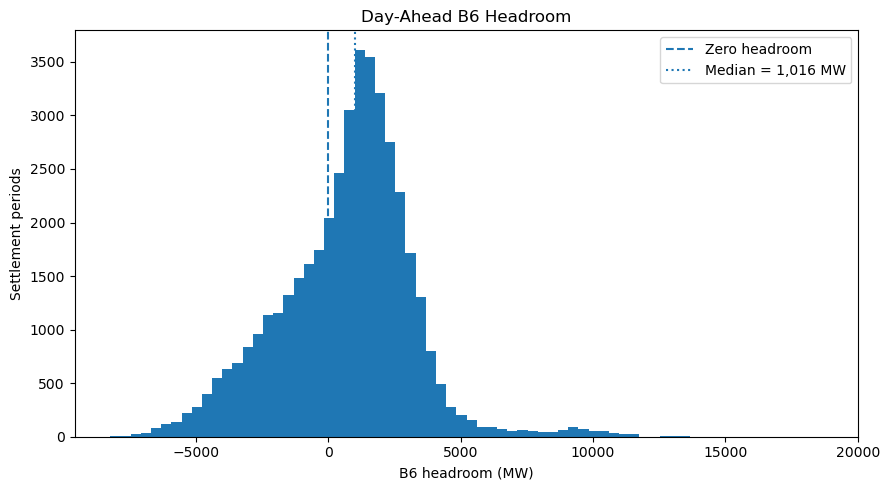

In [708]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(
    full["b6_headroom_mw"],
    bins=70
)

ax.axvline(
    0,
    linewidth=1.5,
    linestyle="--",
    label="Zero headroom"
)

ax.axvline(
    full["b6_headroom_mw"].median(),
    linewidth=1.5,
    linestyle=":",
    label=f"Median = {full['b6_headroom_mw'].median():,.0f} MW"
)

ax.set_title("Day-Ahead B6 Headroom")
ax.set_xlabel("B6 headroom (MW)")
ax.set_ylabel("Settlement periods")
ax.legend()

plt.tight_layout()
plt.show()

#### B6 headroom characteristics

Median B6 headroom is about 1.0 GW, while roughly one third of settlement periods have negative headroom.

The distribution has a long positive tail. Some very high values occur during unusual published B6-limit states, including the 10,000 MW regime examined later in the robustness analysis. High headroom can also occur when forecast flow is in the opposite direction.

The wide range of values means that B6 conditions vary considerably across the sample, rather than simply switching between constrained and unconstrained states.

### 4.3 B6 headroom and Scottish wind BOA

I next compare Scottish downward wind BOA activity across different levels of B6 headroom.

Settlement periods are divided into ten equally sized groups. Decile 1 contains the lowest B6 headroom values, so these are the periods where the published day-ahead B6 position appears tightest. Decile 10 contains the highest headroom values.

This is a descriptive comparison. At this stage, it does not separate the effect of B6 conditions from other factors such as wind output.

In [709]:
eda = full.copy()

eda["headroom_decile"] = (
    pd.qcut(
        eda["b6_headroom_mw"].rank(method="first"),
        q=10,
        labels=False
    ) + 1
)

decile_summary = (
    eda.groupby("headroom_decile", observed=True)
    .agg(
        min_headroom_mw=("b6_headroom_mw", "min"),
        max_headroom_mw=("b6_headroom_mw", "max"),
        periods=("b6_headroom_mw", "size"),
        boa_event_rate=("scottish_downward_boa_event", "mean"),
        mean_boa_mw=("scottish_downward_boa_mw", "mean")
    )
)

decile_summary["boa_event_rate_pct"] = (
    100 * decile_summary["boa_event_rate"]
)

decile_summary[
    [
        "min_headroom_mw",
        "max_headroom_mw",
        "periods",
        "boa_event_rate_pct",
        "mean_boa_mw"
    ]
].round(1)

,min_headroom_mw,max_headroom_mw,periods,boa_event_rate_pct,mean_boa_mw
headroom_decile,,,,,
1,-8225.0,-2763.0,4234,99.8,3638.1
2,-2763.0,-1351.0,4233,96.3,2308.0
3,-1351.0,-326.0,4233,90.1,1417.2
4,-326.0,473.0,4233,78.6,994.1
5,473.0,1016.0,4233,65.9,885.4
6,1016.0,1463.0,4233,51.3,642.5
7,1463.0,1936.0,4233,44.1,500.0
8,1937.0,2496.0,4233,32.6,320.0
9,2496.0,3294.0,4233,20.4,189.0


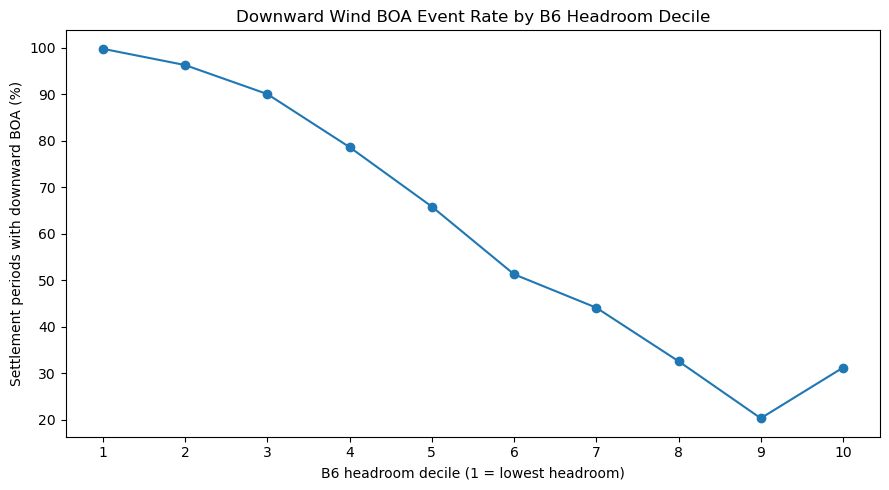

In [710]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(
    decile_summary.index,
    decile_summary["boa_event_rate_pct"],
    marker="o"
)

ax.set_title("Downward Wind BOA Event Rate by B6 Headroom Decile")
ax.set_xlabel("B6 headroom decile (1 = lowest headroom)")
ax.set_ylabel("Settlement periods with downward BOA (%)")
ax.set_xticks(range(1, 11))

plt.tight_layout()
plt.show()

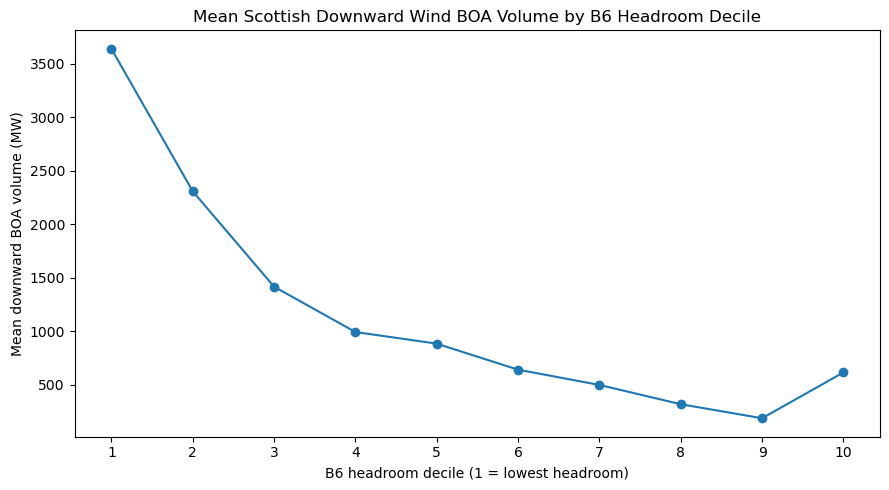

In [711]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(
    decile_summary.index,
    decile_summary["mean_boa_mw"],
    marker="o"
)

ax.set_title("Mean Scottish Downward Wind BOA Volume by B6 Headroom Decile")
ax.set_xlabel("B6 headroom decile (1 = lowest headroom)")
ax.set_ylabel("Mean downward BOA volume (MW)")
ax.set_xticks(range(1, 11))

plt.tight_layout()
plt.show()

#### Unconditional relationship with B6 headroom

There is a clear relationship between B6 headroom and subsequent Scottish downward wind BOA activity.

Across deciles 1 to 9, both the probability of a downward BOA event and the average volume generally fall as B6 headroom increases. In the lowest-headroom decile, downward BOA activity occurs in almost every settlement period and the mean volume is more than 3.6 GW. By decile 9, the event rate is about 20% and mean volume is below 0.2 GW.

Decile 10 breaks this pattern. Both event frequency and mean BOA volume rise again at the highest headroom values. This group contains unusual B6 states, including the 10,000 MW published-limit regime and periods where forecast flow is in the opposite direction. These observations are kept in the main sample and examined separately later.

The pattern is strong, but it should not be treated as causal. High wind conditions can reduce B6 headroom while also increasing the likelihood of Scottish wind being turned down. The next step is therefore to examine whether B6 headroom still contains useful information after forecast wind and demand are taken into account.

### 4.4 Wind as a confounding system condition

The relationship in the previous section may partly reflect wind conditions rather than B6 alone.

High forecast wind can be associated with greater pressure on north-to-south transfers and with a greater need to turn wind generation down. Forecast wind is therefore an important variable to account for before deciding whether B6 headroom adds useful information of its own.

This section uses the verified-wind sample, where the day-ahead wind forecast can be shown to have been available before delivery.

In [712]:
correlation_summary = pd.Series({
    "wind_vs_b6_headroom": (
        wind["wind_forecast_mw"]
        .corr(wind["b6_headroom_mw"])
    ),
    "wind_vs_boa_volume": (
        wind["wind_forecast_mw"]
        .corr(wind["scottish_downward_boa_mw"])
    ),
    "wind_vs_boa_event": (
        wind["wind_forecast_mw"]
        .corr(wind["scottish_downward_boa_event"])
    ),
    "demand_vs_boa_event": (
        wind["demand_forecast_mw"]
        .corr(wind["scottish_downward_boa_event"])
    ),
    "residual_demand_vs_boa_event": (
        wind["residual_demand_forecast_mw"]
        .corr(wind["scottish_downward_boa_event"])
    )
})

correlation_summary.round(3)

wind_vs_b6_headroom            -0.508
wind_vs_boa_volume              0.742
wind_vs_boa_event               0.583
demand_vs_boa_event            -0.029
residual_demand_vs_boa_event   -0.405
dtype: float64

#### Wind as a confounding system condition

Forecast wind is strongly associated with both B6 conditions and subsequent Scottish downward wind BOA activity.

The correlation between forecast wind and B6 headroom is -0.51, while forecast wind is positively correlated with both downward BOA volume (0.74) and event occurrence (0.58).

This is why the unconditional relationship between B6 headroom and BOA activity cannot be read as a causal effect. High-wind conditions can simultaneously reduce B6 headroom and increase downward balancing requirements.

Demand forecast alone has only a weak relationship with the BOA outcome in this sample, while residual demand is more strongly associated with balancing activity.

### 4.5 B6 headroom within similar wind conditions

The previous section shows that wind is strongly related to both B6 headroom and Scottish downward wind BOA activity.

To make the comparison more like-for-like, I divide the verified-wind sample into five forecast-wind groups. Within each group, I then split settlement periods into five B6 headroom groups.

This does not remove every possible difference between the observations, but it shows whether the B6 pattern is still visible among periods with broadly similar forecast-wind conditions.

In [713]:
wind_eda = wind.copy()

wind_eda["wind_quintile"] = pd.qcut(
    wind_eda["wind_forecast_mw"],
    q=5,
    labels=[
        "Q1 low wind",
        "Q2",
        "Q3",
        "Q4",
        "Q5 high wind"
    ]
)

wind_eda["headroom_quintile_within_wind"] = (
    wind_eda
    .groupby(
        "wind_quintile",
        observed=True
    )["b6_headroom_mw"]
    .transform(
        lambda x: pd.qcut(
            x.rank(method="first"),
            q=5,
            labels=False
        ) + 1
    )
)

In [714]:
conditional_summary = (
    wind_eda
    .groupby(
        [
            "wind_quintile",
            "headroom_quintile_within_wind"
        ],
        observed=True
    )
    .agg(
        periods=(
            "scottish_downward_boa_event",
            "size"
        ),
        mean_headroom_mw=(
            "b6_headroom_mw",
            "mean"
        ),
        boa_event_rate=(
            "scottish_downward_boa_event",
            "mean"
        )
    )
    .reset_index()
)

conditional_summary["boa_event_rate_pct"] = (
    100 * conditional_summary["boa_event_rate"]
)

In [715]:
wind_headroom_event_table = (
    conditional_summary
    .pivot(
        index="wind_quintile",
        columns="headroom_quintile_within_wind",
        values="boa_event_rate_pct"
    )
)

wind_headroom_event_table.columns = [
    "H1 lowest",
    "H2",
    "H3",
    "H4",
    "H5 highest"
]

wind_headroom_event_table.round(1)

,H1 lowest,H2,H3,H4,H5 highest
wind_quintile,,,,,
Q1 low wind,37.7,17.0,9.0,5.5,4.4
Q2,79.5,53.0,36.2,27.8,16.8
Q3,96.0,86.4,66.9,55.9,35.5
Q4,98.5,95.9,91.4,75.6,54.2
Q5 high wind,99.9,98.8,99.4,96.4,94.3


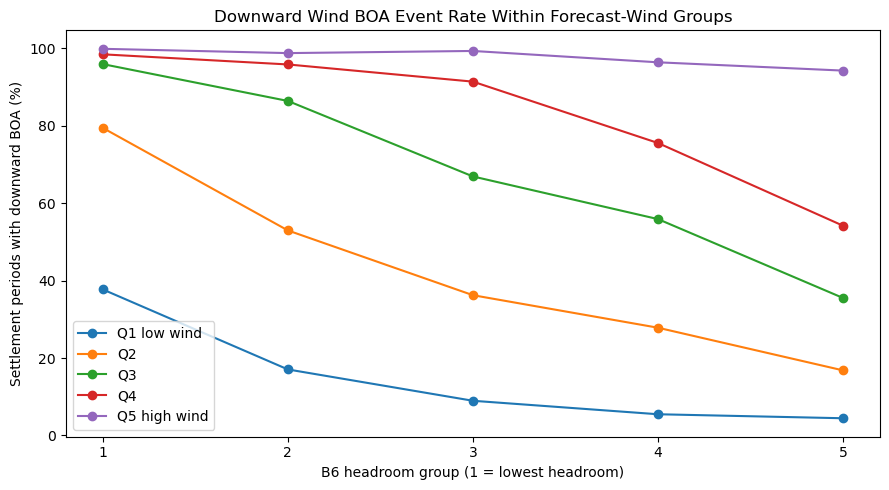

In [716]:
fig, ax = plt.subplots(figsize=(9, 5))

for label, group in conditional_summary.groupby(
    "wind_quintile",
    observed=True
):
    ax.plot(
        group["headroom_quintile_within_wind"],
        group["boa_event_rate_pct"],
        marker="o",
        label=str(label)
    )

ax.set_title(
    "Downward Wind BOA Event Rate Within Forecast-Wind Groups"
)
ax.set_xlabel(
    "B6 headroom group (1 = lowest headroom)"
)
ax.set_ylabel(
    "Settlement periods with downward BOA (%)"
)
ax.set_xticks(range(1, 6))
ax.legend()

plt.tight_layout()
plt.show()

#### B6 headroom conditional on forecast wind

The B6 pattern remains visible after grouping periods by forecast wind.

Within the first four wind groups, the event rate generally falls as B6 headroom increases. In the middle wind group, for example, downward BOA activity occurs in about 96% of the lowest-headroom periods compared with about 36% of the highest-headroom periods.

The highest-wind group behaves differently. Downward BOA activity occurs in more than 94% of periods across all five headroom groups. At very high forecast wind levels, event occurrence is therefore close to saturated, so B6 headroom has less room to separate periods with and without an event.

This is still a descriptive comparison rather than a causal result. It does, however, suggest that the relationship between B6 headroom and downward BOA activity is not explained by broad forecast-wind conditions alone. The modelling section tests this more formally using wind, demand and calendar controls.

# 5. Predictive modelling

The descriptive analysis shows a strong relationship between B6 headroom and Scottish downward wind BOA activity, but forecast wind is related to both.

The modelling stage asks a narrower question: does B6 headroom improve prediction once forecast wind, forecast demand and calendar effects are already included?

The models are evaluated chronologically rather than using a random split. This keeps the ordering of the data intact and makes the exercise closer to predicting later system conditions from earlier observations.

### 5.1 Chronological evaluation design

In [717]:
dates = np.sort(wind["settlement_date"].unique())

split_idx = int(len(dates) * 0.80)
split_date = dates[split_idx]

train = wind[
    wind["settlement_date"] < split_date
].copy()

test = wind[
    wind["settlement_date"] >= split_date
].copy()

split_summary = pd.DataFrame({
    "sample": ["earlier sample", "later evaluation"],
    "rows": [len(train), len(test)],
    "days": [
        train["settlement_date"].nunique(),
        test["settlement_date"].nunique()
    ],
    "first_date": [
        train["settlement_date"].min(),
        test["settlement_date"].min()
    ],
    "last_date": [
        train["settlement_date"].max(),
        test["settlement_date"].max()
    ],
    "boa_event_rate_pct": [
        100 * train["scottish_downward_boa_event"].mean(),
        100 * test["scottish_downward_boa_event"].mean()
    ]
})

split_summary.round(1)

,sample,rows,days,first_date,last_date,boa_event_rate_pct
0,earlier sample,25198,525,2024-04-22,2025-10-06,59.3
1,later evaluation,6334,132,2025-10-07,2026-04-23,69.1


The earlier sample contains 25,198 settlement periods and is used to fit the initial models. The later evaluation sample contains 6,334 periods.

The downward BOA event rate rises from about 59% in the earlier sample to 69% in the later period. The data distribution is therefore not completely stable through time, which makes the later period a more demanding evaluation than a randomly mixed train-test split.

This later sample was used during exploratory model development, so it is treated as a chronological evaluation period rather than a completely untouched confirmatory test set. A separate rolling temporal robustness check is added later to test whether the B6 improvement is repeated across different time windows.

### 5.2 Event model specification

The first modelling task predicts whether a Scottish downward wind BOA event occurs in each settlement period.

I compare two logistic regression models.

The baseline model uses forecast wind, forecast demand and calendar variables:

$$
M_0:
\Pr(C_t > 0)
=
f(W_t, D_t, \text{calendar}_t)
$$

The B6 model uses the same variables and adds day-ahead B6 headroom:

$$
M_1:
\Pr(C_t > 0)
=
f(W_t, D_t, \text{calendar}_t, H_t^{B6})
$$

The comparison tests whether B6 headroom improves prediction beyond information already available from general system conditions.

In [718]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    brier_score_loss,
    log_loss
)

In [719]:
continuous_m0 = [
    "wind_forecast_mw",
    "demand_forecast_mw"
]

continuous_m1 = [
    "wind_forecast_mw",
    "demand_forecast_mw",
    "b6_headroom_mw"
]

categorical_features = [
    "month",
    "day_of_week",
    "settlement_period"
]

target = "scottish_downward_boa_event"

features_m0 = continuous_m0 + categorical_features
features_m1 = continuous_m1 + categorical_features

y_train = train[target]
y_test = test[target]

### 5.3 Event-model results


In [720]:
def make_logit(continuous_features):
    preprocessor = ColumnTransformer(
        transformers=[
            ("continuous", StandardScaler(), continuous_features),
            (
                "categorical",
                OneHotEncoder(
                    handle_unknown="ignore",
                    drop="first"
                ),
                categorical_features
            )
        ]
    )

    return Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", LogisticRegression(max_iter=2000))
        ]
    )


m0 = make_logit(continuous_m0)
m1 = make_logit(continuous_m1)

features_m0 = continuous_m0 + categorical_features
features_m1 = continuous_m1 + categorical_features

m0.fit(train[features_m0], y_train)
m1.fit(train[features_m1], y_train)

p_m0 = m0.predict_proba(test[features_m0])[:, 1]
p_m1 = m1.predict_proba(test[features_m1])[:, 1]

# Simple benchmark: training-sample event prevalence
p_naive = np.full(len(y_test), y_train.mean())

In [721]:
results = pd.DataFrame({
    "Model": [
        "Naive prevalence",
        "M0: wind + demand + calendar",
        "M1: M0 + B6 headroom"
    ],
    "ROC_AUC": [
        roc_auc_score(y_test, p_naive),
        roc_auc_score(y_test, p_m0),
        roc_auc_score(y_test, p_m1)
    ],
    "Average_Precision": [
        average_precision_score(y_test, p_naive),
        average_precision_score(y_test, p_m0),
        average_precision_score(y_test, p_m1)
    ],
    "Brier_Score": [
        brier_score_loss(y_test, p_naive),
        brier_score_loss(y_test, p_m0),
        brier_score_loss(y_test, p_m1)
    ],
    "Log_Loss": [
        log_loss(y_test, p_naive),
        log_loss(y_test, p_m0),
        log_loss(y_test, p_m1)
    ]
})

results.round(4)

,Model,ROC_AUC,Average_Precision,Brier_Score,Log_Loss
0,Naive prevalence,0.5000,0.6909,0.2231,0.6388
1,M0: wind + demand + calendar,0.8171,0.9088,0.1720,0.5302
2,M1: M0 + B6 headroom,0.8622,0.9359,0.1494,0.4748


The baseline model already performs well, which shows that forecast wind, demand and calendar timing explain a large part of when downward wind BOA activity occurs.

Adding B6 headroom improves every reported metric. ROC AUC rises from 0.817 to 0.862 and average precision rises from 0.909 to 0.936. The Brier score also falls from 0.172 to 0.149.

B6 headroom therefore adds predictive information beyond the other day-ahead variables included in the model.

This is a predictive result rather than a causal estimate. B6 headroom may also reflect wider transmission conditions that are related to Scottish wind balancing activity.

### 5.4 Temporal probability calibration

The event model is later combined with a model of positive BOA volume, so the predicted probabilities need to be meaningful as probabilities rather than only useful for ranking high-risk periods.

To preserve the time ordering of the data, the earlier sample is split again. The first part is used to fit the logistic regression model and the later part is used only to calibrate its probabilities.

Platt scaling is used for calibration. This fits a logistic mapping from the model's raw score to the observed event probability using the separate calibration period.

In [722]:
train_dates = np.sort(
    train["settlement_date"].unique()
)

cal_split_idx = int(
    len(train_dates) * 0.80
)

cal_split_date = train_dates[
    cal_split_idx
]

fit_train = train[
    train["settlement_date"] < cal_split_date
].copy()

cal_train = train[
    train["settlement_date"] >= cal_split_date
].copy()

calibration_split_summary = pd.DataFrame({
    "sample": [
        "model fit",
        "probability calibration",
        "later evaluation"
    ],
    "rows": [
        len(fit_train),
        len(cal_train),
        len(test)
    ],
    "first_date": [
        fit_train["settlement_date"].min(),
        cal_train["settlement_date"].min(),
        test["settlement_date"].min()
    ],
    "last_date": [
        fit_train["settlement_date"].max(),
        cal_train["settlement_date"].max(),
        test["settlement_date"].max()
    ],
    "event_rate_pct": [
        100 * fit_train[target].mean(),
        100 * cal_train[target].mean(),
        100 * test[target].mean()
    ]
})

calibration_split_summary.round(1)

,sample,rows,first_date,last_date,event_rate_pct
0,model fit,20158,2024-04-22,2025-06-19,59.7
1,probability calibration,5040,2025-06-20,2025-10-06,58.0
2,later evaluation,6334,2025-10-07,2026-04-23,69.1


The calibration block comes after the model-fitting block and before the later evaluation period. This keeps the probability adjustment separate from the observations used to estimate the underlying event model.

The event rate is higher in the later evaluation period, which again shows that the system conditions are not completely stable through time.

In [723]:
# Fit a fresh B6 model using only the earlier model-fit period
m1_fit = make_logit(continuous_m1)

m1_fit.fit(
    fit_train[features_m1],
    fit_train[target]
)

# Raw model scores
score_cal = m1_fit.decision_function(
    cal_train[features_m1]
)

score_test = m1_fit.decision_function(
    test[features_m1]
)

# Raw probabilities from the same fit-only model
p_uncalibrated = m1_fit.predict_proba(
    test[features_m1]
)[:, 1]

In [724]:
platt = LogisticRegression()

platt.fit(
    score_cal.reshape(-1, 1),
    cal_train[target]
)

p_platt = platt.predict_proba(
    score_test.reshape(-1, 1)
)[:, 1]

In [725]:
calibration_results = pd.DataFrame({
    "Model": [
        "Uncalibrated M1",
        "Platt-calibrated M1"
    ],
    "ROC_AUC": [
        roc_auc_score(y_test, p_uncalibrated),
        roc_auc_score(y_test, p_platt)
    ],
    "Average_Precision": [
        average_precision_score(y_test, p_uncalibrated),
        average_precision_score(y_test, p_platt)
    ],
    "Brier_Score": [
        brier_score_loss(y_test, p_uncalibrated),
        brier_score_loss(y_test, p_platt)
    ],
    "Log_Loss": [
        log_loss(y_test, p_uncalibrated),
        log_loss(y_test, p_platt)
    ]
})

calibration_results.round(4)

,Model,ROC_AUC,Average_Precision,Brier_Score,Log_Loss
0,Uncalibrated M1,0.8626,0.9365,0.1497,0.4754
1,Platt-calibrated M1,0.8626,0.9365,0.1422,0.4356


#### Effect of temporal probability calibration

Calibration leaves ROC AUC and average precision unchanged because it does not change how the model ranks settlement periods.

The probability-based metrics improve. The Brier score falls from 0.150 to 0.142 and log loss falls from 0.475 to 0.436.

The calibrated probabilities are therefore used when the event and magnitude models are combined later in the notebook.

In [726]:
cal_compare = pd.DataFrame({
    "actual": y_test.to_numpy(),
    "uncalibrated": p_uncalibrated,
    "platt": p_platt
})

def calibration_table(df, probability_col, bins=10):
    temp = df[["actual", probability_col]].copy()

    temp["bin"] = pd.qcut(
        temp[probability_col],
        q=bins,
        duplicates="drop"
    )

    result = (
        temp.groupby("bin", observed=True)
        .agg(
            periods=("actual", "size"),
            mean_predicted=(probability_col, "mean"),
            observed_rate=("actual", "mean")
        )
        .reset_index()
    )

    return result


cal_uncal = calibration_table(cal_compare, "uncalibrated")
cal_platt = calibration_table(cal_compare, "platt")

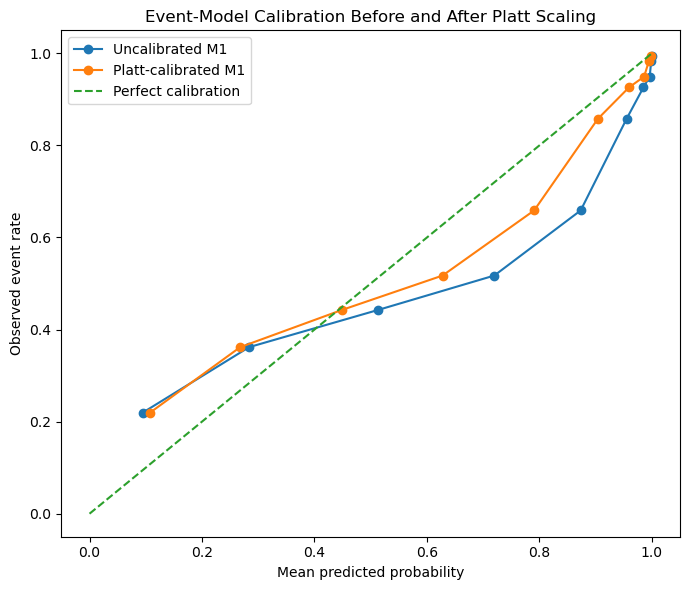

In [727]:
fig, ax = plt.subplots(figsize=(7, 6))

ax.plot(
    cal_uncal["mean_predicted"],
    cal_uncal["observed_rate"],
    marker="o",
    label="Uncalibrated M1"
)

ax.plot(
    cal_platt["mean_predicted"],
    cal_platt["observed_rate"],
    marker="o",
    label="Platt-calibrated M1"
)

ax.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Perfect calibration"
)

ax.set_xlabel("Mean predicted probability")
ax.set_ylabel("Observed event rate")
ax.set_title("Event-Model Calibration Before and After Platt Scaling")
ax.legend()

plt.tight_layout()
plt.show()

Platt scaling brings the observed event rates closer to the predicted probabilities across much of the range. Some differences remain, particularly in the middle of the probability distribution, so the probabilities should not be treated as exact risk estimates.

### 5.5 Positive-event magnitude

The event model predicts whether downward wind BOA activity occurs. The second stage looks at how large the observed volume is when activity is positive.

Because the outcome is strictly positive in this part of the sample and is right-skewed, I use Gamma regression with a log link.

I first compare a baseline model using forecast wind, forecast demand and calendar variables with the same model after adding B6 headroom.

In [728]:
train_pos = train[
    train["scottish_downward_boa_mw"] > 0
].copy()

test_pos = test[
    test["scottish_downward_boa_mw"] > 0
].copy()

positive_sample_summary = pd.DataFrame({
    "sample": ["earlier sample", "later evaluation"],
    "rows": [len(train_pos), len(test_pos)],
    "mean_boa_mw": [
        train_pos["scottish_downward_boa_mw"].mean(),
        test_pos["scottish_downward_boa_mw"].mean()
    ]
})

positive_sample_summary.round(1)

,sample,rows,mean_boa_mw
0,earlier sample,14948,1747.8
1,later evaluation,4376,2242.2


In [729]:
from sklearn.metrics import mean_gamma_deviance

magnitude_results = pd.DataFrame({
    "Model": [
        "Naive train mean",
        "G0: controls only",
        "G1: controls + linear B6"
    ],
    "MAE": [
        mean_absolute_error(
            y_test_pos,
            np.full(len(y_test_pos), y_train_pos.mean())
        ),
        mean_absolute_error(y_test_pos, pred_g0),
        mean_absolute_error(y_test_pos, pred_g1)
    ],
    "RMSE": [
        mean_squared_error(
            y_test_pos,
            np.full(len(y_test_pos), y_train_pos.mean())
        ) ** 0.5,
        mean_squared_error(y_test_pos, pred_g0) ** 0.5,
        mean_squared_error(y_test_pos, pred_g1) ** 0.5
    ],
    "R2": [
        r2_score(
            y_test_pos,
            np.full(len(y_test_pos), y_train_pos.mean())
        ),
        r2_score(y_test_pos, pred_g0),
        r2_score(y_test_pos, pred_g1)
    ],
    "Gamma_Deviance": [
        mean_gamma_deviance(
            y_test_pos,
            np.full(len(y_test_pos), y_train_pos.mean())
        ),
        mean_gamma_deviance(y_test_pos, pred_g0),
        mean_gamma_deviance(y_test_pos, pred_g1)
    ]
})

magnitude_results.round(3)
)

SyntaxError: unmatched ')' (3654239950.py, line 44)

#### Temporal shift in positive-event magnitude

Mean downward wind BOA volume, conditional on an event occurring, rises from about 1,748 MW in the earlier sample to 2,242 MW in the later evaluation period.

That shift is another reason to evaluate the models chronologically rather than using a random split.

In [ ]:
from sklearn.metrics import mean_gamma_deviance

magnitude_results = pd.DataFrame({
    "Model": [
        "Naive train mean",
        "G0: controls only",
        "G1: controls + linear B6"
    ],
    "MAE": [
        mean_absolute_error(
            y_test_pos,
            np.full(len(y_test_pos), y_train_pos.mean())
        ),
        mean_absolute_error(y_test_pos, pred_g0),
        mean_absolute_error(y_test_pos, pred_g1)
    ],
    "RMSE": [
        mean_squared_error(
            y_test_pos,
            np.full(len(y_test_pos), y_train_pos.mean())
        ) ** 0.5,
        mean_squared_error(y_test_pos, pred_g0) ** 0.5,
        mean_squared_error(y_test_pos, pred_g1) ** 0.5
    ],
    "R2": [
        r2_score(
            y_test_pos,
            np.full(len(y_test_pos), y_train_pos.mean())
        ),
        r2_score(y_test_pos, pred_g0),
        r2_score(y_test_pos, pred_g1)
    ],
    "Gamma_Deviance": [
        mean_gamma_deviance(
            y_test_pos,
            np.full(len(y_test_pos), y_train_pos.mean())
        ),
        mean_gamma_deviance(y_test_pos, pred_g0),
        mean_gamma_deviance(y_test_pos, pred_g1)
    ]
})

magnitude_results.round(3)

NameError: name 'y_test_pos' is not defined

In [ ]:
magnitude_results = pd.DataFrame({
    "Model": [
        "Naive train mean",
        "G0: wind + demand + calendar",
        "G1: G0 + B6 headroom"
    ],
    "MAE": [
        mean_absolute_error(
            y_test_pos,
            np.full(len(y_test_pos), y_train_pos.mean())
        ),
        mean_absolute_error(y_test_pos, pred_g0),
        mean_absolute_error(y_test_pos, pred_g1)
    ],
    "RMSE": [
        mean_squared_error(
            y_test_pos,
            np.full(len(y_test_pos), y_train_pos.mean())
        ) ** 0.5,
        mean_squared_error(y_test_pos, pred_g0) ** 0.5,
        mean_squared_error(y_test_pos, pred_g1) ** 0.5
    ],
    "R2": [
        r2_score(
            y_test_pos,
            np.full(len(y_test_pos), y_train_pos.mean())
        ),
        r2_score(y_test_pos, pred_g0),
        r2_score(y_test_pos, pred_g1)
    ]
})

magnitude_results.round(1)

,Model,MAE,RMSE,R2
0,Naive train mean,1357.4,1670.7,-0.1
1,G0: wind + demand + calendar,1010.7,1286.8,0.3
2,G1: G0 + B6 headroom,1044.7,1362.0,0.3


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import GammaRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    mean_gamma_deviance
)

continuous_m0 = [
    "wind_forecast_mw",
    "demand_forecast_mw"
]

continuous_m1 = [
    "wind_forecast_mw",
    "demand_forecast_mw",
    "b6_headroom_mw"
]

categorical_features = [
    "month",
    "day_of_week",
    "settlement_period"
]

features_m0 = continuous_m0 + categorical_features
features_m1 = continuous_m1 + categorical_features


def make_gamma(continuous_features):
    preprocessor = ColumnTransformer(
        transformers=[
            (
                "continuous",
                StandardScaler(),
                continuous_features
            ),
            (
                "categorical",
                OneHotEncoder(
                    handle_unknown="ignore",
                    drop="first"
                ),
                categorical_features
            )
        ]
    )

    return Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            (
                "model",
                GammaRegressor(
                    alpha=0.1,
                    max_iter=2000
                )
            )
        ]
    )


y_train_pos = train_pos["scottish_downward_boa_mw"]
y_test_pos = test_pos["scottish_downward_boa_mw"]

g0 = make_gamma(continuous_m0)
g1 = make_gamma(continuous_m1)

g0.fit(
    train_pos[features_m0],
    y_train_pos
)

g1.fit(
    train_pos[features_m1],
    y_train_pos
)

pred_g0 = g0.predict(
    test_pos[features_m0]
)

pred_g1 = g1.predict(
    test_pos[features_m1]
)

print("Magnitude models fitted successfully.")

Magnitude models fitted successfully.


#### Incremental value of B6 for positive-event magnitude

The baseline Gamma model using forecast wind, forecast demand and calendar controls materially outperforms the naive benchmark.

Adding B6 headroom as a single linear term does not improve conventional out-of-sample magnitude accuracy. MAE increases from 1,011 MW to 1,045 MW, RMSE increases from 1,287 MW to 1,362 MW, and \(R^2\) falls from 0.350 to 0.272.

Gamma deviance falls marginally from 0.828 to 0.824, however, so the evidence is not completely uniform across loss functions. Given the nonlinear B6 relationships observed during exploratory analysis, nonlinear specifications are evaluated using an internal chronological validation sample before any further use of the final test period.

In [ ]:
from sklearn.metrics import mean_gamma_deviance

magnitude_diagnostics = pd.DataFrame({
    "Model": [
        "Naive train mean",
        "G0: wind + demand + calendar",
        "G1: G0 + linear B6 headroom"
    ],
    "MAE": [
        mean_absolute_error(
            y_test_pos,
            np.full(len(y_test_pos), y_train_pos.mean())
        ),
        mean_absolute_error(y_test_pos, pred_g0),
        mean_absolute_error(y_test_pos, pred_g1)
    ],
    "RMSE": [
        mean_squared_error(
            y_test_pos,
            np.full(len(y_test_pos), y_train_pos.mean())
        ) ** 0.5,
        mean_squared_error(y_test_pos, pred_g0) ** 0.5,
        mean_squared_error(y_test_pos, pred_g1) ** 0.5
    ],
    "R2": [
        r2_score(
            y_test_pos,
            np.full(len(y_test_pos), y_train_pos.mean())
        ),
        r2_score(y_test_pos, pred_g0),
        r2_score(y_test_pos, pred_g1)
    ],
    "Gamma_Deviance": [
        mean_gamma_deviance(
            y_test_pos,
            np.full(len(y_test_pos), y_train_pos.mean())
        ),
        mean_gamma_deviance(y_test_pos, pred_g0),
        mean_gamma_deviance(y_test_pos, pred_g1)
    ]
})

magnitude_diagnostics.round(4)

,Model,MAE,RMSE,R2,Gamma_Deviance
0,Naive train mean,1357.4468,1670.6815,-0.0960,1.1669
1,G0: wind + demand + calendar,1010.6654,1286.8223,0.3498,0.8277
2,G1: G0 + linear B6 headroom,1044.7386,1361.9953,0.2716,0.8241


In [ ]:
#### Later-evaluation positive-event magnitude comparison

The nonlinear B6 specification also modestly outperforms the controls-only magnitude model in the later evaluation period.

MAE falls from about 1,011 MW to 997 MW and Gamma deviance falls from 0.828 to 0.799. Changes in RMSE and \(R^2\) are smaller.

Taken together with the internal validation results, this suggests that B6 contains some additional information about positive-event magnitude, but the contribution is much weaker than its contribution to predicting event occurrence.

The later evaluation period had already been inspected during earlier exploratory development, so this result is treated as supporting evidence rather than a completely untouched confirmatory test.

### 5.6 Nonlinear B6 magnitude specification

The linear B6 specification does not improve positive-event magnitude prediction. The exploratory analysis, however, suggests that the relationship between B6 headroom and downward BOA volume is nonlinear.

I therefore compare three magnitude specifications using a later validation block taken from within the earlier modelling sample:

- G0: forecast wind, forecast demand and calendar controls
- G1: the same controls plus linear B6 headroom
- G2: the same controls plus a nonlinear spline for B6 headroom and an indicator for the 10,000 MW B6-limit state

Model selection is carried out using this internal chronological validation period rather than the later evaluation sample.

In [ ]:
train_dates = np.sort(
    train["settlement_date"].unique()
)

magnitude_split_idx = int(
    len(train_dates) * 0.80
)

magnitude_split_date = train_dates[
    magnitude_split_idx
]

fit_train_pos = train_pos[
    train_pos["settlement_date"] < magnitude_split_date
].copy()

val_train_pos = train_pos[
    train_pos["settlement_date"] >= magnitude_split_date
].copy()


magnitude_split_summary = pd.DataFrame({
    "sample": [
        "model fit",
        "internal validation"
    ],
    "rows": [
        len(fit_train_pos),
        len(val_train_pos)
    ],
    "first_date": [
        fit_train_pos["settlement_date"].min(),
        val_train_pos["settlement_date"].min()
    ],
    "last_date": [
        fit_train_pos["settlement_date"].max(),
        val_train_pos["settlement_date"].max()
    ],
    "mean_positive_boa_mw": [
        fit_train_pos["scottish_downward_boa_mw"].mean(),
        val_train_pos["scottish_downward_boa_mw"].mean()
    ]
})

magnitude_split_summary.round(1)

,sample,rows,first_date,last_date,mean_positive_boa_mw
0,model fit,12027,2024-04-22,2025-06-19,1669.1
1,internal validation,2921,2025-06-20,2025-10-06,2071.7


The internal magnitude-validation period is also more severe than the earlier model-fit period. Mean positive downward BOA increases from approximately 1,669 MW to 2,072 MW, a rise of about 24%.

Candidate magnitude specifications are therefore being selected under genuine temporal distribution shift rather than a randomly mixed validation sample.

Mean positive downward BOA rises from about 1,669 MW in the model-fit period to 2,072 MW in the internal validation period.

The validation period therefore represents a noticeably different operating environment rather than a randomly mixed sample.

In [ ]:
magnitude_regime_summary = pd.DataFrame({
    "sample": [
        "model fit",
        "internal validation"
    ],
    "positive_rows": [
        len(fit_train_pos),
        len(val_train_pos)
    ],
    "b6_10000_rows": [
        fit_train_pos["b6_limit_10000_flag"].sum(),
        val_train_pos["b6_limit_10000_flag"].sum()
    ],
    "b6_10000_pct": [
        100 * fit_train_pos["b6_limit_10000_flag"].mean(),
        100 * val_train_pos["b6_limit_10000_flag"].mean()
    ],
    "mean_headroom_mw": [
        fit_train_pos["b6_headroom_mw"].mean(),
        val_train_pos["b6_headroom_mw"].mean()
    ]
})

magnitude_regime_summary.round(2)

,sample,positive_rows,b6_10000_rows,b6_10000_pct,mean_headroom_mw
0,model fit,12027,330,2.74,-194.03
1,internal validation,2921,169,5.79,127.70


The 10,000 MW B6-limit state appears in both periods, although its prevalence rises from about 2.7% to 5.8%. Mean B6 headroom also changes between the two periods.

This gives the validation block a different mix of B6 operating conditions from the period used to fit the candidate models.

In [ ]:
g0_val = make_gamma(continuous_m0)
g1_val = make_gamma(continuous_m1)

g0_val.fit(
    fit_train_pos[features_m0],
    fit_train_pos["scottish_downward_boa_mw"]
)

g1_val.fit(
    fit_train_pos[features_m1],
    fit_train_pos["scottish_downward_boa_mw"]
)

pred_g0_val = g0_val.predict(
    val_train_pos[features_m0]
)

pred_g1_val = g1_val.predict(
    val_train_pos[features_m1]
)

In [ ]:
from sklearn.preprocessing import SplineTransformer

features_g2 = [
    "wind_forecast_mw",
    "demand_forecast_mw",
    "b6_headroom_mw",
    "b6_limit_10000_flag",
    "month",
    "day_of_week",
    "settlement_period"
]


def make_gamma_spline():

    preprocessor = ColumnTransformer(
        transformers=[
            (
                "system_conditions",
                StandardScaler(),
                [
                    "wind_forecast_mw",
                    "demand_forecast_mw"
                ]
            ),
            (
                "b6_spline",
                SplineTransformer(
                    n_knots=5,
                    degree=3,
                    include_bias=False,
                    knots="quantile"
                ),
                ["b6_headroom_mw"]
            ),
            (
                "b6_regime",
                "passthrough",
                ["b6_limit_10000_flag"]
            ),
            (
                "calendar",
                OneHotEncoder(
                    handle_unknown="ignore",
                    drop="first"
                ),
                categorical_features
            )
        ]
    )

    return Pipeline(
        steps=[
            (
                "preprocessor",
                preprocessor
            ),
            (
                "model",
                GammaRegressor(
                    alpha=0.1,
                    max_iter=2000
                )
            )
        ]
    )

In [ ]:
g2_val = make_gamma_spline()

g2_val.fit(
    fit_train_pos[features_g2],
    fit_train_pos["scottish_downward_boa_mw"]
)

pred_g2_val = g2_val.predict(
    val_train_pos[features_g2]
)

In [ ]:
from sklearn.metrics import mean_gamma_deviance

y_val_pos = (
    val_train_pos["scottish_downward_boa_mw"]
)

validation_results = pd.DataFrame({
    "Model": [
        "G0: controls only",
        "G1: + linear B6 headroom",
        "G2: + spline B6 + 10GW flag"
    ],
    "MAE": [
        mean_absolute_error(y_val_pos, pred_g0_val),
        mean_absolute_error(y_val_pos, pred_g1_val),
        mean_absolute_error(y_val_pos, pred_g2_val)
    ],
    "RMSE": [
        mean_squared_error(y_val_pos, pred_g0_val) ** 0.5,
        mean_squared_error(y_val_pos, pred_g1_val) ** 0.5,
        mean_squared_error(y_val_pos, pred_g2_val) ** 0.5
    ],
    "R2": [
        r2_score(y_val_pos, pred_g0_val),
        r2_score(y_val_pos, pred_g1_val),
        r2_score(y_val_pos, pred_g2_val)
    ],
    "Gamma_Deviance": [
        mean_gamma_deviance(y_val_pos, pred_g0_val),
        mean_gamma_deviance(y_val_pos, pred_g1_val),
        mean_gamma_deviance(y_val_pos, pred_g2_val)
    ]
})

validation_results.round(4)

,Model,MAE,RMSE,R2,Gamma_Deviance
0,G0: controls only,949.4288,1233.4878,0.4066,1.2125
1,G1: + linear B6 headroom,982.9833,1304.0236,0.3368,1.2467
2,G2: + spline B6 + 10GW flag,930.0147,1220.9159,0.4187,1.1898


The linear B6 specification performs worse than the controls-only model on the internal validation period.

The nonlinear specification performs better. Relative to the controls-only model, MAE falls from about 949 MW to 930 MW, RMSE falls from 1,233 MW to 1,221 MW and \(R^2\) rises from 0.407 to 0.419. Gamma deviance also falls from 1.213 to 1.190.

The improvement is modest, but it is consistent across the reported metrics. This suggests that the relationship between B6 conditions and positive-event magnitude is better represented nonlinearly than by a single linear headroom term.

In [ ]:
g2_final = make_gamma_spline()

g2_final.fit(
    train_pos[features_g2],
    y_train_pos
)

pred_g2_test = g2_final.predict(
    test_pos[features_g2]
)

In [ ]:
final_magnitude_comparison = pd.DataFrame({
    "Model": [
        "G0: controls only",
        "G2: spline B6 + 10GW flag"
    ],
    "MAE": [
        mean_absolute_error(
            y_test_pos,
            pred_g0
        ),
        mean_absolute_error(
            y_test_pos,
            pred_g2_test
        )
    ],
    "RMSE": [
        mean_squared_error(
            y_test_pos,
            pred_g0
        ) ** 0.5,
        mean_squared_error(
            y_test_pos,
            pred_g2_test
        ) ** 0.5
    ],
    "R2": [
        r2_score(
            y_test_pos,
            pred_g0
        ),
        r2_score(
            y_test_pos,
            pred_g2_test
        )
    ],
    "Gamma_Deviance": [
        mean_gamma_deviance(
            y_test_pos,
            pred_g0
        ),
        mean_gamma_deviance(
            y_test_pos,
            pred_g2_test
        )
    ]
})

final_magnitude_comparison.round(4)

,Model,MAE,RMSE,R2,Gamma_Deviance
0,G0: controls only,1010.6654,1286.8223,0.3498,0.8277
1,G2: spline B6 + 10GW flag,996.5497,1282.3391,0.3543,0.7992


In [ ]:
pd.DataFrame({
    "sample": ["fit", "validation"],
    "positive_rows": [
        len(fit_train_pos),
        len(val_train_pos)
    ],
    "b6_10000_rows": [
        fit_train_pos["b6_limit_10000_flag"].sum(),
        val_train_pos["b6_limit_10000_flag"].sum()
    ],
    "b6_10000_pct": [
        100 * fit_train_pos["b6_limit_10000_flag"].mean(),
        100 * val_train_pos["b6_limit_10000_flag"].mean()
    ],
    "mean_headroom_mw": [
        fit_train_pos["b6_headroom_mw"].mean(),
        val_train_pos["b6_headroom_mw"].mean()
    ]
}).round(2)

,sample,positive_rows,b6_10000_rows,b6_10000_pct,mean_headroom_mw
0,fit,12027,330,2.74,-194.03
1,validation,2921,169,5.79,127.70


The 10,000 MW B6-limit state is present in both the model-fit and validation periods, although its prevalence rises from 2.7% to 5.8%. Mean B6 headroom also shifts from approximately -194 MW to +128 MW. The validation block therefore contains a different mix of B6 operating conditions rather than simply reproducing the training distribution.

In [ ]:
print("test rows:", len(test))
print("calibrated probabilities:", len(p_platt))
print("G2 ready:", g2_final is not None)

test rows: 6334
calibrated probabilities: 6334
G2 ready: True


In [ ]:
g0_val = make_gamma(continuous_m0)
g1_val = make_gamma(continuous_m1)

g0_val.fit(
    fit_train_pos[features_m0],
    fit_train_pos["scottish_downward_boa_mw"]
)

g1_val.fit(
    fit_train_pos[features_m1],
    fit_train_pos["scottish_downward_boa_mw"]
)

pred_g0_val = g0_val.predict(
    val_train_pos[features_m0]
)

pred_g1_val = g1_val.predict(
    val_train_pos[features_m1]
)

In [ ]:
from sklearn.preprocessing import SplineTransformer


In [ ]:
def make_gamma_spline():
    preprocessor = ColumnTransformer(
        transformers=[
            (
                "system_conditions",
                StandardScaler(),
                [
                    "wind_forecast_mw",
                    "demand_forecast_mw"
                ]
            ),
            (
                "b6_spline",
                SplineTransformer(
                    n_knots=5,
                    degree=3,
                    include_bias=False,
                    knots="quantile"
                ),
                ["b6_headroom_mw"]
            ),
            (
                "b6_regime",
                "passthrough",
                ["b6_limit_10000_flag"]
            ),
            (
                "calendar",
                OneHotEncoder(
                    handle_unknown="ignore",
                    drop="first"
                ),
                categorical_features
            )
        ]
    )

    return Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            (
                "model",
                GammaRegressor(
                    alpha=0.1,
                    max_iter=2000
                )
            )
        ]
    )

In [ ]:
g2_val = make_gamma_spline()

features_g2 = [
    "wind_forecast_mw",
    "demand_forecast_mw",
    "b6_headroom_mw",
    "b6_limit_10000_flag",
    "month",
    "day_of_week",
    "settlement_period"
]

g2_val.fit(
    fit_train_pos[features_g2],
    fit_train_pos["scottish_downward_boa_mw"]
)

pred_g2_val = g2_val.predict(
    val_train_pos[features_g2]
)

In [ ]:
y_val_pos = val_train_pos["scottish_downward_boa_mw"]

validation_results = pd.DataFrame({
    "Model": [
        "G0: controls only",
        "G1: + linear B6 headroom",
        "G2: + spline B6 + 10GW flag"
    ],
    "MAE": [
        mean_absolute_error(y_val_pos, pred_g0_val),
        mean_absolute_error(y_val_pos, pred_g1_val),
        mean_absolute_error(y_val_pos, pred_g2_val)
    ],
    "RMSE": [
        mean_squared_error(y_val_pos, pred_g0_val) ** 0.5,
        mean_squared_error(y_val_pos, pred_g1_val) ** 0.5,
        mean_squared_error(y_val_pos, pred_g2_val) ** 0.5
    ],
    "R2": [
        r2_score(y_val_pos, pred_g0_val),
        r2_score(y_val_pos, pred_g1_val),
        r2_score(y_val_pos, pred_g2_val)
    ],
    "Gamma_Deviance": [
        mean_gamma_deviance(y_val_pos, pred_g0_val),
        mean_gamma_deviance(y_val_pos, pred_g1_val),
        mean_gamma_deviance(y_val_pos, pred_g2_val)
    ]
})

validation_results.round(4)

,Model,MAE,RMSE,R2,Gamma_Deviance
0,G0: controls only,949.4288,1233.4878,0.4066,1.2125
1,G1: + linear B6 headroom,982.9833,1304.0236,0.3368,1.2467
2,G2: + spline B6 + 10GW flag,930.0147,1220.9159,0.4187,1.1898


#### Nonlinear B6 magnitude specification

On the internal chronological validation period, adding B6 headroom as a single linear term worsens magnitude prediction relative to the controls-only model.

Allowing the B6 relationship to be nonlinear through a cubic spline, while separately identifying the 10,000 MW limit regime, performs better than both alternatives. Relative to the controls-only model, MAE falls from approximately 949 MW to 930 MW, RMSE falls from 1,233 MW to 1,221 MW, \(R^2\) rises from 0.407 to 0.419, and Gamma deviance falls from 1.213 to 1.190.

The improvement is modest but consistent across the evaluation metrics. The result points to a nonlinear relationship between B6 headroom and positive-event magnitude rather than one that is well described by a single linear term.

In [ ]:
g2_final = make_gamma_spline()

g2_final.fit(
    train_pos[features_g2],
    y_train_pos
)

pred_g2_test = g2_final.predict(
    test_pos[features_g2]
)

In [ ]:
final_magnitude_comparison = pd.DataFrame({
    "Model": [
        "G0: controls only",
        "G2: spline B6 + 10GW flag"
    ],
    "MAE": [
        mean_absolute_error(y_test_pos, pred_g0),
        mean_absolute_error(y_test_pos, pred_g2_test)
    ],
    "RMSE": [
        mean_squared_error(y_test_pos, pred_g0) ** 0.5,
        mean_squared_error(y_test_pos, pred_g2_test) ** 0.5
    ],
    "R2": [
        r2_score(y_test_pos, pred_g0),
        r2_score(y_test_pos, pred_g2_test)
    ],
    "Gamma_Deviance": [
        mean_gamma_deviance(y_test_pos, pred_g0),
        mean_gamma_deviance(y_test_pos, pred_g2_test)
    ]
})

final_magnitude_comparison.round(4)

,Model,MAE,RMSE,R2,Gamma_Deviance
0,G0: controls only,1010.6654,1286.8223,0.3498,0.8277
1,G2: spline B6 + 10GW flag,996.5497,1282.3391,0.3543,0.7992


### 5.7 Combined expected downward BOA

The two stages can be combined to estimate expected Scottish downward wind BOA volume for each settlement period.

The event model estimates the probability that downward BOA activity occurs, while the magnitude model estimates the expected volume conditional on an event.

$$
E(C_t \mid X_t)
=
P(C_t > 0 \mid X_t)
\times
E(C_t \mid C_t > 0, X_t)
$$

For the B6-enhanced specification, I combine the temporally calibrated event probability with the nonlinear positive-event magnitude model selected in the previous section.

In [ ]:
pred_g2_all_test = g2_final.predict(
    test[features_g2]
)

expected_boa_test = (
    p_platt * pred_g2_all_test
)

actual_boa_test = (
    test["scottish_downward_boa_mw"].to_numpy()
)

In [ ]:
combined_results = pd.Series({
    "test_periods": len(test),
    "actual_mean_boa_mw": actual_boa_test.mean(),
    "predicted_mean_boa_mw": expected_boa_test.mean(),
    "mae_mw": mean_absolute_error(
        actual_boa_test,
        expected_boa_test
    ),
    "rmse_mw": mean_squared_error(
        actual_boa_test,
        expected_boa_test
    ) ** 0.5,
    "r2": r2_score(
        actual_boa_test,
        expected_boa_test
    )
})

combined_results.round(2)

test_periods             6334.00
actual_mean_boa_mw       1549.10
predicted_mean_boa_mw    1779.71
mae_mw                    860.09
rmse_mw                  1192.90
r2                          0.50
dtype: float64

#### Combined expected-volume performance

Combining the calibrated event probability with the conditional magnitude model produces an unconditional settlement-period forecast of Scottish downward wind BOA volume.

Across the 6,334-period later evaluation sample, the model achieves an MAE of approximately 860 MW, an RMSE of 1,193 MW and an \(R^2\) of 0.50.

The model overpredicts the average outcome: mean predicted downward BOA is approximately 1,780 MW compared with an observed mean of 1,549 MW, an upward bias of about 231 MW (15%). This indicates that useful explanatory and predictive power remains alongside systematic level error under the later system regime.

In [ ]:
# Baseline event model fitted on the same early fit period
m0_fit = make_logit(continuous_m0)

m0_fit.fit(
    fit_train[features_m0],
    fit_train[target]
)

# Scores for temporal calibration
score_cal_m0 = m0_fit.decision_function(
    cal_train[features_m0]
)

score_test_m0 = m0_fit.decision_function(
    test[features_m0]
)

# Platt calibration
platt_m0 = LogisticRegression()

platt_m0.fit(
    score_cal_m0.reshape(-1, 1),
    cal_train[target]
)

p_platt_m0 = platt_m0.predict_proba(
    score_test_m0.reshape(-1, 1)
)[:, 1]

In [ ]:
pred_g0_all_test = g0.predict(
    test[features_m0]
)

expected_boa_baseline = (
    p_platt_m0 * pred_g0_all_test
)

In [ ]:
combined_comparison = pd.DataFrame({
    "Model": [
        "Baseline: controls only",
        "B6-enhanced two-part model"
    ],
    "MAE": [
        mean_absolute_error(
            actual_boa_test,
            expected_boa_baseline
        ),
        mean_absolute_error(
            actual_boa_test,
            expected_boa_test
        )
    ],
    "RMSE": [
        mean_squared_error(
            actual_boa_test,
            expected_boa_baseline
        ) ** 0.5,
        mean_squared_error(
            actual_boa_test,
            expected_boa_test
        ) ** 0.5
    ],
    "R2": [
        r2_score(
            actual_boa_test,
            expected_boa_baseline
        ),
        r2_score(
            actual_boa_test,
            expected_boa_test
        )
    ],
    "Mean_Predicted_MW": [
        expected_boa_baseline.mean(),
        expected_boa_test.mean()
    ]
})

combined_comparison.round(2)

,Model,MAE,RMSE,R2,Mean_Predicted_MW
0,Baseline: controls only,899.80,1230.76,0.47,1745.93
1,B6-enhanced two-part model,860.09,1192.90,0.50,1779.71


#### Incremental value of B6 in the combined model

Adding B6 information improves the complete two-part model in the later evaluation period.

MAE falls from about 900 MW to 860 MW and RMSE falls from about 1,231 MW to 1,193 MW. The \(R^2\) increases from approximately 0.47 to 0.50.

Most of the predictive information still comes from forecast wind, forecast demand and calendar conditions. B6 therefore adds incremental rather than dominant predictive value.

Its strongest contribution is to predicting whether Scottish downward wind BOA activity occurs. The improvement in conditional event magnitude is smaller and requires a nonlinear B6 specification.

### 6.1 Excluding the 10,000 MW B6-limit regime

The main analysis retains periods where the published B6 transfer limit is 10,000 MW. These observations are unusual relative to the rest of the sample, so I test whether the main result depends on them.

The first check removes 10,000 MW periods from the later evaluation sample while leaving the fitted models unchanged. This asks whether the reported improvement from B6 is concentrated in those unusual observations.

In [ ]:
normal_b6_mask = (
    test["b6_limit_10000_flag"].to_numpy() == 0
)

actual_normal = actual_boa_test[normal_b6_mask]

baseline_normal = expected_boa_baseline[normal_b6_mask]

b6_normal = expected_boa_test[normal_b6_mask]

print(
    "Excluded 10GW periods:",
    (~normal_b6_mask).sum()
)

print(
    "Remaining periods:",
    normal_b6_mask.sum()
)

Excluded 10GW periods: 46
Remaining periods: 6288


In [ ]:
robustness_10gw = pd.DataFrame({
    "Model": [
        "Controls-only baseline",
        "B6-enhanced model"
    ],
    "MAE": [
        mean_absolute_error(
            actual_normal,
            baseline_normal
        ),
        mean_absolute_error(
            actual_normal,
            b6_normal
        )
    ],
    "RMSE": [
        mean_squared_error(
            actual_normal,
            baseline_normal
        ) ** 0.5,
        mean_squared_error(
            actual_normal,
            b6_normal
        ) ** 0.5
    ],
    "R2": [
        r2_score(
            actual_normal,
            baseline_normal
        ),
        r2_score(
            actual_normal,
            b6_normal
        )
    ]
})

robustness_10gw.round(2)

,Model,MAE,RMSE,R2
0,Controls-only baseline,900.48,1231.65,0.46
1,B6-enhanced model,860.00,1191.83,0.50


#### Excluding 10,000 MW periods from evaluation

Forty-six settlement periods in the final evaluation sample have a published B6 limit of 10,000 MW. Removing these periods leaves 6,288 observations.

The B6-enhanced model continues to outperform the controls-only system. MAE falls from approximately 900 MW to 860 MW, RMSE falls from 1,232 MW to 1,192 MW, and \(R^2\) remains approximately 0.50 compared with 0.46 for the baseline.

The headline predictive improvement is therefore not concentrated in the unusual 10,000 MW observations present in the evaluation period.

### 6.2 Removing the 10,000 MW regime throughout the modelling process

The previous check removed 10,000 MW periods only from the later evaluation sample. A stricter test removes these observations from model fitting, probability calibration and final evaluation before re-estimating the two-part models.

This checks whether the estimated contribution of B6 depends on the unusual regime entering the modelling process at any stage.

In [ ]:
fit_no10 = fit_train[
    fit_train["b6_limit_10000_flag"] == 0
].copy()

cal_no10 = cal_train[
    cal_train["b6_limit_10000_flag"] == 0
].copy()

train_pos_no10 = train_pos[
    train_pos["b6_limit_10000_flag"] == 0
].copy()

test_no10 = test[
    test["b6_limit_10000_flag"] == 0
].copy()

print("Event fit rows:", len(fit_no10))
print("Calibration rows:", len(cal_no10))
print("Positive magnitude train rows:", len(train_pos_no10))
print("Final test rows:", len(test_no10))

Event fit rows: 19770
Calibration rows: 4865
Positive magnitude train rows: 14449
Final test rows: 6288


#### Re-estimation after complete 10,000 MW exclusion

All event and magnitude models are re-estimated after removing the 10,000 MW B6-limit state from model fitting, probability calibration and evaluation.

Because this regime is absent by construction, the nonlinear magnitude specification retains the B6 headroom spline but does not include the 10,000 MW indicator.

In [ ]:
# Controls-only event model
m0_no10 = make_logit(continuous_m0)

m0_no10.fit(
    fit_no10[features_m0],
    fit_no10[target]
)

# B6-enhanced event model
m1_no10 = make_logit(continuous_m1)

m1_no10.fit(
    fit_no10[features_m1],
    fit_no10[target]
)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('continuous', ...), ('categorical', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [ ]:
# M0 temporal calibration
score_cal_m0_no10 = m0_no10.decision_function(
    cal_no10[features_m0]
)

score_test_m0_no10 = m0_no10.decision_function(
    test_no10[features_m0]
)

platt_m0_no10 = LogisticRegression()

platt_m0_no10.fit(
    score_cal_m0_no10.reshape(-1, 1),
    cal_no10[target]
)

p_m0_no10 = platt_m0_no10.predict_proba(
    score_test_m0_no10.reshape(-1, 1)
)[:, 1]


# M1 temporal calibration
score_cal_m1_no10 = m1_no10.decision_function(
    cal_no10[features_m1]
)

score_test_m1_no10 = m1_no10.decision_function(
    test_no10[features_m1]
)

platt_m1_no10 = LogisticRegression()

platt_m1_no10.fit(
    score_cal_m1_no10.reshape(-1, 1),
    cal_no10[target]
)

p_m1_no10 = platt_m1_no10.predict_proba(
    score_test_m1_no10.reshape(-1, 1)
)[:, 1]

In [ ]:
test_pos_no10 = test_no10[
    test_no10["scottish_downward_boa_mw"] > 0
].copy()

g0_no10 = make_gamma(continuous_m0)

g0_no10.fit(
    train_pos_no10[features_m0],
    train_pos_no10["scottish_downward_boa_mw"]
)

pred_g0_no10_all = g0_no10.predict(
    test_no10[features_m0]
)

In [ ]:
def make_gamma_spline_no10():
    preprocessor = ColumnTransformer(
        transformers=[
            (
                "system_conditions",
                StandardScaler(),
                [
                    "wind_forecast_mw",
                    "demand_forecast_mw"
                ]
            ),
            (
                "b6_spline",
                SplineTransformer(
                    n_knots=5,
                    degree=3,
                    include_bias=False,
                    knots="quantile"
                ),
                ["b6_headroom_mw"]
            ),
            (
                "calendar",
                OneHotEncoder(
                    handle_unknown="ignore",
                    drop="first"
                ),
                categorical_features
            )
        ]
    )

    return Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            (
                "model",
                GammaRegressor(
                    alpha=0.1,
                    max_iter=2000
                )
            )
        ]
    )

In [ ]:
features_g2_no10 = [
    "wind_forecast_mw",
    "demand_forecast_mw",
    "b6_headroom_mw",
    "month",
    "day_of_week",
    "settlement_period"
]

g2_no10 = make_gamma_spline_no10()

g2_no10.fit(
    train_pos_no10[features_g2_no10],
    train_pos_no10["scottish_downward_boa_mw"]
)

pred_g2_no10_all = g2_no10.predict(
    test_no10[features_g2_no10]
)

In [ ]:
actual_no10 = test_no10[
    "scottish_downward_boa_mw"
].to_numpy()

expected_baseline_no10 = (
    p_m0_no10 * pred_g0_no10_all
)

expected_b6_no10 = (
    p_m1_no10 * pred_g2_no10_all
)

In [ ]:
strict_no10_results = pd.DataFrame({
    "Model": [
        "Controls-only baseline",
        "B6-enhanced model"
    ],
    "MAE": [
        mean_absolute_error(
            actual_no10,
            expected_baseline_no10
        ),
        mean_absolute_error(
            actual_no10,
            expected_b6_no10
        )
    ],
    "RMSE": [
        mean_squared_error(
            actual_no10,
            expected_baseline_no10
        ) ** 0.5,
        mean_squared_error(
            actual_no10,
            expected_b6_no10
        ) ** 0.5
    ],
    "R2": [
        r2_score(
            actual_no10,
            expected_baseline_no10
        ),
        r2_score(
            actual_no10,
            expected_b6_no10
        )
    ],
    "Mean_Predicted_MW": [
        expected_baseline_no10.mean(),
        expected_b6_no10.mean()
    ],
    "Actual_Mean_MW": [
        actual_no10.mean(),
        actual_no10.mean()
    ]
})

strict_no10_results.round(2)

,Model,MAE,RMSE,R2,Mean_Predicted_MW,Actual_Mean_MW
0,Controls-only baseline,892.93,1223.64,0.47,1721.31,1542.67
1,B6-enhanced model,840.26,1172.79,0.51,1743.89,1542.67


#### Strict exclusion of the 10,000 MW regime

The main result remains after completely removing the 10,000 MW B6-limit regime from model fitting, probability calibration, magnitude estimation and final evaluation.

On the resulting 6,288-period evaluation sample, the controls-only system produces an MAE of approximately 893 MW and an RMSE of 1,224 MW, with \(R^2=0.47\).

The B6-enhanced system reduces MAE to approximately 840 MW and RMSE to 1,173 MW, while \(R^2\) rises to 0.51. This corresponds to reductions of approximately 5.9% in MAE and 4.2% in RMSE.

The incremental predictive value of B6 therefore persists when the unusual 10,000 MW regime is excluded from the entire modelling workflow rather than merely removed from evaluation.

The B6-enhanced model continues to overpredict the overall level of downward BOA in the later period, indicating that temporal level shift remains a separate limitation.

### 6.3 Alternative definition of B6 stress

The main specification uses continuous B6 headroom, measured as the published transfer limit minus forecast flow.

As a robustness check, I replace this with a simpler binary indicator equal to one when B6 headroom is negative. This removes information about the degree of tightness and asks whether a coarse signal of B6 stress still improves event prediction.

In [ ]:
for df in [train, test]:
    df["b6_negative_headroom_flag"] = (
        df["b6_headroom_mw"] < 0
    ).astype(int)

In [ ]:
continuous_binary = [
    "wind_forecast_mw",
    "demand_forecast_mw"
]

features_binary = (
    continuous_binary
    + ["b6_negative_headroom_flag"]
    + categorical_features
)

In [ ]:
def make_logit_binary():

    preprocessor = ColumnTransformer(
        transformers=[
            (
                "continuous",
                StandardScaler(),
                continuous_binary
            ),
            (
                "b6_binary",
                "passthrough",
                ["b6_negative_headroom_flag"]
            ),
            (
                "categorical",
                OneHotEncoder(
                    handle_unknown="ignore",
                    drop="first"
                ),
                categorical_features
            )
        ]
    )

    return Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            (
                "model",
                LogisticRegression(
                    max_iter=2000
                )
            )
        ]
    )

In [ ]:
m_binary = make_logit_binary()

m_binary.fit(
    train[features_binary],
    y_train
)

p_binary = m_binary.predict_proba(
    test[features_binary]
)[:, 1]

In [ ]:
temporal_robustness = test_no10[
    ["settlement_date", "scottish_downward_boa_mw"]
].copy()

temporal_robustness["baseline_prediction"] = expected_baseline_no10
temporal_robustness["b6_prediction"] = expected_b6_no10

temporal_robustness["baseline_abs_error"] = (
    temporal_robustness["scottish_downward_boa_mw"]
    - temporal_robustness["baseline_prediction"]
).abs()

temporal_robustness["b6_abs_error"] = (
    temporal_robustness["scottish_downward_boa_mw"]
    - temporal_robustness["b6_prediction"]
).abs()

temporal_robustness["month_period"] = (
    temporal_robustness["settlement_date"]
    .dt.to_period("M")
)

In [ ]:
alternative_b6_event = pd.DataFrame({
    "Model": [
        "Controls only",
        "Binary negative-headroom flag",
        "Continuous B6 headroom"
    ],
    "ROC_AUC": [
        roc_auc_score(y_test, p_m0),
        roc_auc_score(y_test, p_binary),
        roc_auc_score(y_test, p_m1)
    ],
    "Average_Precision": [
        average_precision_score(y_test, p_m0),
        average_precision_score(y_test, p_binary),
        average_precision_score(y_test, p_m1)
    ],
    "Brier_Score": [
        brier_score_loss(y_test, p_m0),
        brier_score_loss(y_test, p_binary),
        brier_score_loss(y_test, p_m1)
    ]
})

alternative_b6_event.round(4)

,Model,ROC_AUC,Average_Precision,Brier_Score
0,Controls only,0.8171,0.9088,0.1720
1,Binary negative-headroom flag,0.8537,0.9333,0.1542
2,Continuous B6 headroom,0.8622,0.9359,0.1494


The result is not dependent on using B6 headroom as a precise continuous measure.

Replacing continuous headroom with a simple indicator for negative headroom still improves event prediction substantially relative to the controls-only model. ROC AUC rises from 0.817 to 0.854, while the Brier score falls from 0.172 to 0.154.

Using continuous B6 headroom performs better again, with ROC AUC of 0.862 and a Brier score of 0.149.

This suggests that both the broad state of B6 and the degree of available headroom contain useful predictive information. The main result is therefore not simply an artefact of one particular numerical representation of the boundary.

### 6.4 Temporal stability

The improvement from B6 is not confined to a single month.

The B6-enhanced model records lower MAE in six of the seven calendar months represented in the later evaluation sample. January 2026 is approximately neutral, with MAE around 0.5% higher than the controls-only model.

The size of the improvement varies through time, so the incremental value of B6 should not be treated as constant across operating conditions. October and November contain relatively few observations in the verified-wind sample, so their monthly estimates should be interpreted more cautiously.

In [ ]:
monthly_days = (
    temporal_robustness
    .groupby("month_period")
    .agg(
        days=("settlement_date", "nunique"),
        periods=("settlement_date", "size"),
        baseline_mae=("baseline_abs_error", "mean"),
        b6_mae=("b6_abs_error", "mean")
    )
)

monthly_days["mae_improvement_pct"] = (
    100
    * (monthly_days["baseline_mae"] - monthly_days["b6_mae"])
    / monthly_days["baseline_mae"]
)

monthly_days.round(1)

,days,periods,baseline_mae,b6_mae,mae_improvement_pct
month_period,,,,,
2025-10,7,336,1297.2,1139.0,12.2
2025-11,2,96,492.3,454.6,7.7
2025-12,31,1462,821.4,705.6,14.1
2026-01,14,672,810.8,815.0,-0.5
2026-02,26,1238,901.9,865.5,4.0
2026-03,30,1428,937.8,925.7,1.3
2026-04,22,1056,880.8,837.6,4.9


In [ ]:
for df in [fit_no10, cal_no10, test_no10]:
    df["b6_negative_headroom_flag"] = (
        df["b6_headroom_mw"] < 0
    ).astype(int)

In [ ]:
continuous_alt = [
    "wind_forecast_mw",
    "demand_forecast_mw"
]

categorical_alt = [
    "month",
    "day_of_week",
    "settlement_period",
    "b6_negative_headroom_flag"
]

def make_logit_alt():
    preprocessor = ColumnTransformer(
        transformers=[
            (
                "continuous",
                StandardScaler(),
                continuous_alt
            ),
            (
                "categorical",
                OneHotEncoder(
                    handle_unknown="ignore",
                    drop="first"
                ),
                categorical_alt
            )
        ]
    )

    return Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", LogisticRegression(max_iter=2000))
        ]
    )

In [ ]:
features_alt = continuous_alt + categorical_alt

m_alt = make_logit_alt()

m_alt.fit(
    fit_no10[features_alt],
    fit_no10[target]
)

score_cal_alt = m_alt.decision_function(
    cal_no10[features_alt]
)

score_test_alt = m_alt.decision_function(
    test_no10[features_alt]
)

platt_alt = LogisticRegression()

platt_alt.fit(
    score_cal_alt.reshape(-1, 1),
    cal_no10[target]
)

p_alt = platt_alt.predict_proba(
    score_test_alt.reshape(-1, 1)
)[:, 1]

In [ ]:
alternative_b6_event = pd.DataFrame({
    "Model": [
        "Controls only",
        "Binary negative-headroom flag",
        "Continuous B6 headroom"
    ],
    "ROC_AUC": [
        roc_auc_score(test_no10[target], p_m0_no10),
        roc_auc_score(test_no10[target], p_alt),
        roc_auc_score(test_no10[target], p_m1_no10)
    ],
    "Average_Precision": [
        average_precision_score(test_no10[target], p_m0_no10),
        average_precision_score(test_no10[target], p_alt),
        average_precision_score(test_no10[target], p_m1_no10)
    ],
    "Brier_Score": [
        brier_score_loss(test_no10[target], p_m0_no10),
        brier_score_loss(test_no10[target], p_alt),
        brier_score_loss(test_no10[target], p_m1_no10)
    ]
})

alternative_b6_event.round(4)

,Model,ROC_AUC,Average_Precision,Brier_Score
0,Controls only,0.8173,0.9106,0.1612
1,Binary negative-headroom flag,0.8533,0.9339,0.1459
2,Continuous B6 headroom,0.8672,0.9390,0.1398


#### Alternative B6 signal definition

The predictive value of B6 is not dependent on the precise continuous headroom specification.

Replacing continuous B6 headroom with a simple binary indicator for negative headroom still materially improves event prediction relative to the controls-only model. ROC AUC rises from 0.817 to 0.853 and the Brier score falls from 0.161 to 0.146.

However, continuous B6 headroom performs better still, with ROC AUC of 0.867 and a Brier score of 0.140.

This suggests that the predictive information in B6 is not limited to whether forecast flow crosses the published transfer limit. The degree of available headroom also contains useful information about subsequent Scottish downward wind BOA risk.

In [732]:
temporal_robustness = pd.DataFrame({
    "settlement_date": test["settlement_date"].to_numpy(),
    "scottish_downward_boa_mw": actual_boa_test,
    "baseline_abs_error": np.abs(
        actual_boa_test - expected_boa_baseline
    ),
    "b6_abs_error": np.abs(
        actual_boa_test - expected_boa_test
    )
})

temporal_robustness["month_period"] = (
    pd.to_datetime(
        temporal_robustness["settlement_date"]
    ).dt.to_period("M")
)

print("Rows:", len(temporal_robustness))


NameError: name 'expected_boa_baseline' is not defined

# 7. Summary of Empirical Findings